<a href="https://colab.research.google.com/github/Pes2ug23am092/AIS_transit_procurement_data_analysis/blob/main/Encephalon_processing_NYNJ.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ---------------------------------------------------------------------------------------------
# CELL 1: OPTIMIZED LOW-RAM DIAGNOSTICS AND INITIAL PREPROCESSING
# ---------------------------------------------------------------------------------------------

import os
import pandas as pd
import geopandas as gpd
from google.colab import drive

# Ensure Drive is mounted
try:
    drive.mount('/content/drive')
except:
    pass

# --- Configuration ---
FINAL_OUTPUT_FILE = '/content/drive/MyDrive/ADA Encephalon/AIS_related/war_processedoutput/combined_east_coast_NYNJ_2020_2024_clean.parquet'

# --- 1. Load ONLY THE NECESSARY LIGHTWEIGHT COLUMNS (Excluding 'geometry') ---
# This is the key optimization to prevent crashes.
COLUMNS_FOR_ANALYSIS = ['MMSI', 'TrackStartTime', 'VesselType', 'Draft_Meters']

print(f"Loading lightweight columns ({', '.join(COLUMNS_FOR_ANALYSIS)}) from: {FINAL_OUTPUT_FILE}")

try:
    # Use pandas read_parquet to specifically load only the non-geometry columns
    df = pd.read_parquet(FINAL_OUTPUT_FILE, columns=COLUMNS_FOR_ANALYSIS)
except Exception as e:
    print(f"ERROR: Could not load file. Check path. Error: {e}")
    raise

print(f"\n✅ Total features (rows) loaded: {len(df):,}")

# --- 2. Diagnostics: NaN Counts and Data Types ---
print("\n--- Diagnostic Checkpoint ---")
print("Column data types:")
df.info()

print("\nMissing Value Analysis (NaN Counts):")
nan_counts = df.isnull().sum()
print(nan_counts)

print("\nDuplicate Analysis:")
duplicate_rows = df.duplicated().sum()
print(f"Total fully duplicated rows found: {duplicate_rows:,}")


# --- 3. Preprocessing: Time Conversion and Feature Engineering ---
print("\n--- Preprocessing: Time Conversion and Feature Engineering ---")

# Convert 'TrackStartTime' to the correct datetime format
df['TrackStartTime'] = pd.to_datetime(df['TrackStartTime'])

# Create necessary features for time-series analysis
df['Year'] = df['TrackStartTime'].dt.year
df['Month'] = df['TrackStartTime'].dt.month
df['Date'] = df['TrackStartTime'].dt.date
print("Successfully converted 'TrackStartTime' and created 'Year', 'Month', 'Date' columns.")

# --- 4. Save the Cleaned, Lightweight File for Aggregation ---
CLEANED_DF_PATH = os.path.join(os.path.dirname(FINAL_OUTPUT_FILE), 'combined_lightweight_clean.parquet')
df.to_parquet(CLEANED_DF_PATH, index=False)

print(f"\n✅ Lightweight, preprocessed data saved to: {CLEANED_DF_PATH}")
print("\nSample of processed data (first 5 rows):")
print(df[['Year', 'Month', 'MMSI', 'VesselType', 'Draft_Meters']].head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading lightweight columns (MMSI, TrackStartTime, VesselType, Draft_Meters) from: /content/drive/MyDrive/ADA Encephalon/AIS_related/war_processedoutput/combined_east_coast_NYNJ_2020_2024_clean.parquet

✅ Total features (rows) loaded: 499,455

--- Diagnostic Checkpoint ---
Column data types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 499455 entries, 0 to 499454
Data columns (total 4 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   MMSI            499455 non-null  int64  
 1   TrackStartTime  499455 non-null  object 
 2   VesselType      472809 non-null  float64
 3   Draft_Meters    140912 non-null  float64
dtypes: float64(2), int64(1), object(1)
memory usage: 15.2+ MB

Missing Value Analysis (NaN Counts):
MMSI                   0
TrackStartTime         0
VesselType         26646
Draft_Meters    

In [ ]:
# ---------------------------------------------------------------------------------------------
# CELL 2: FILTER NOISE AND AGGREGATE TO MONTHLY TIME SERIES
# ---------------------------------------------------------------------------------------------

import os
import pandas as pd
import numpy as np
from google.colab import drive

# Ensure Drive is mounted
try:
    drive.mount('/content/drive')
except:
    pass

# --- Configuration ---
CLEANED_DF_PATH = '/content/drive/MyDrive/ADA Encephalon/AIS_related/war_processedoutput/combined_lightweight_clean.parquet'
FINAL_AGGREGATE_PATH = os.path.join(os.path.dirname(CLEANED_DF_PATH), 'monthly_trade_analysis_2020_2024.csv')

# --- 1. Load the lightweight preprocessed DataFrame ---
print(f"Loading preprocessed data from: {CLEANED_DF_PATH}")
df = pd.read_parquet(CLEANED_DF_PATH)


# --- 2. Step: Remove NaNs in Draft_Meters and VesselType ---
print(f"\nTotal rows before filtering: {len(df):,}")

# Remove rows where Draft_Meters is NaN (critical for trade volume analysis)
df_clean = df.dropna(subset=['Draft_Meters'])
print(f"Rows remaining after removing NaN Draft_Meters: {len(df_clean):,}")

# The remaining NaNs in VesselType are few, but we will filter by type anyway.
# We will temporarily fill the remaining few NaN VesselType records with 0 for the filtering step
df_clean['VesselType'] = df_clean['VesselType'].fillna(0).astype(int)


# --- 3. Step: Filter by Relevant Vessel Types (Remove Noise) ---
# We focus on major international trade vessels: Cargo, Tanker, and Passenger
# VesselType Codes: 60-69 (Passenger), 70-79 (Cargo), 80-89 (Tanker)

trade_vessel_codes = (df_clean['VesselType'] >= 60) & (df_clean['VesselType'] <= 89)

df_clean_filtered = df_clean[trade_vessel_codes].copy()

print(f"Rows remaining after filtering to major trade vessels: {len(df_clean_filtered):,}")


# --- 4. Step: Aggregate to Monthly Time Series ---

# Calculate the mean Draft_Meters (Volume Proxy) and unique MMSI count (Frequency Proxy) per month
monthly_df = df_clean_filtered.groupby(['Year', 'Month']).agg(
    # Primary Metrics
    Average_Draft_Meters=('Draft_Meters', 'mean'),
    Unique_Vessel_Count=('MMSI', 'nunique'),
    Total_Observations=('MMSI', 'size'),
    # Time Index Creation
).reset_index()

# Convert Year and Month columns to a single Date column for time series plotting
monthly_df['Time_Period'] = pd.to_datetime(monthly_df['Year'].astype(str) + '-' + monthly_df['Month'].astype(str) + '-01')

# Final formatting and column selection
monthly_df = monthly_df[['Time_Period', 'Year', 'Month', 'Average_Draft_Meters', 'Unique_Vessel_Count', 'Total_Observations']]


# --- 5. Save the Final Analysis-Ready Data ---
monthly_df.to_csv(FINAL_AGGREGATE_PATH, index=False)

print("\n--- Aggregation Complete ---")
print(f"Final analysis-ready data contains {len(monthly_df)} monthly periods.")
print(f"Final monthly time series dataset saved to: {FINAL_AGGREGATE_PATH}")

print("\nSample of the final time series data:")
print(monthly_df.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading preprocessed data from: /content/drive/MyDrive/ADA Encephalon/AIS_related/war_processedoutput/combined_lightweight_clean.parquet

Total rows before filtering: 499,455
Rows remaining after removing NaN Draft_Meters: 140,912
Rows remaining after filtering to major trade vessels: 80,540

--- Aggregation Complete ---
Final analysis-ready data contains 60 monthly periods.
Final monthly time series dataset saved to: /content/drive/MyDrive/ADA Encephalon/AIS_related/war_processedoutput/monthly_trade_analysis_2020_2024.csv

Sample of the final time series data:
  Time_Period  Year  Month  Average_Draft_Meters  Unique_Vessel_Count  \
0  2020-01-01  2020      1              0.506060                  245   
1  2020-02-01  2020      2              0.529248                  206   
2  2020-03-01  2020      3              0.640795                  225   
3  2020-04-

/tmp/ipython-input-735641063.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['VesselType'] = df_clean['VesselType'].fillna(0).astype(int)


Data loaded for visualization (2020-2024). Total 60 months.


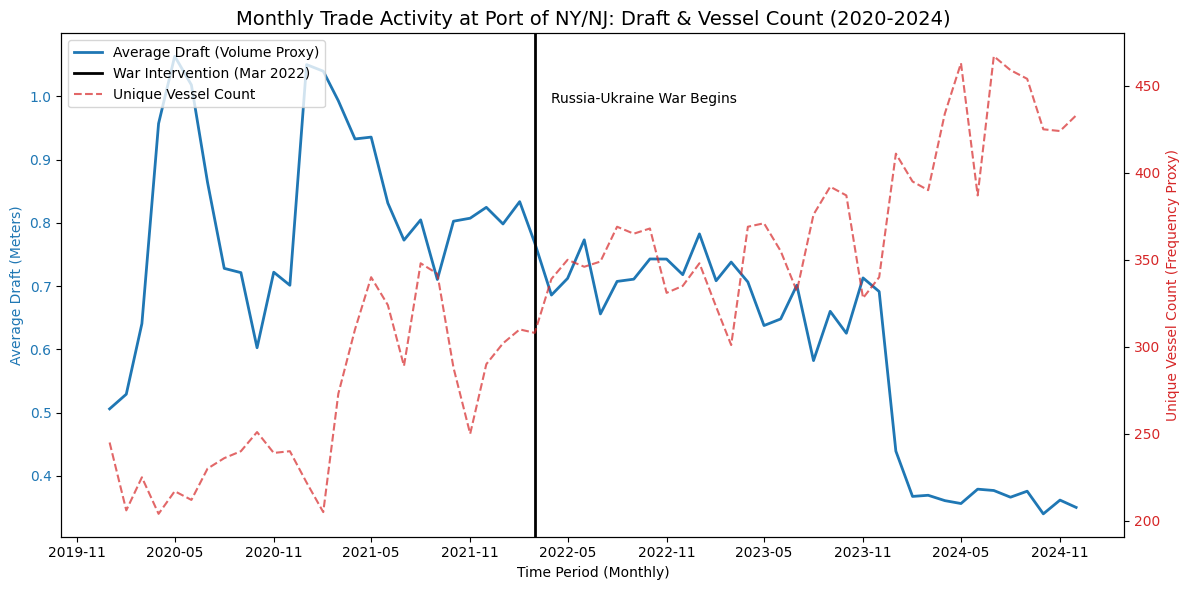


--- Next Steps for Causal Inference ---
1. **Analyze the Plot:** Look for any sudden, sustained shifts in the blue (Draft) and red (Vessel Count) lines after the black vertical line (Mar 2022).
2. **Create Dummy Variables:** For your regression model, you need two new columns based on the INTERVENTION_DATE:
   - **T:** Time variable (0 before Mar 2022, 1 after).
   - **X:** Slope variable (Cumulative months since Jan 2020).
3. **Run Regression:** Use Ordinary Least Squares (OLS) regression on your time series data to quantify the war's impact.


In [ ]:
# ---------------------------------------------------------------------------------------------
# CELL 3: VISUALIZATION AND CAUSAL ANALYSIS SETUP
# ---------------------------------------------------------------------------------------------

import pandas as pd
import matplotlib.pyplot as plt
import os
import matplotlib.dates as mdates

# --- Configuration ---
FINAL_AGGREGATE_PATH = '/content/drive/MyDrive/ADA Encephalon/AIS_related/war_processedoutput/monthly_trade_analysis_2020_2024.csv'

# Load the final analysis-ready dataset
monthly_df = pd.read_csv(FINAL_AGGREGATE_PATH)

# Ensure the Time_Period column is datetime for plotting
monthly_df['Time_Period'] = pd.to_datetime(monthly_df['Time_Period'])

print(f"Data loaded for visualization (2020-2024). Total {len(monthly_df)} months.")

# --- Define the Intervention Point (Russia-Ukraine War Start) ---
# The large-scale invasion started on February 24, 2022.
# We will set the intervention marker to March 2022 to capture the immediate response.
INTERVENTION_DATE = pd.to_datetime('2022-03-01')


# --- Plotting the Two Key Variables on Separate Y-Axes (Twin Axis Plot) ---

fig, ax1 = plt.subplots(figsize=(12, 6))

# 1. Plot Average Draft (Volume Proxy) - Left Y-axis
color = 'tab:blue'
ax1.set_xlabel('Time Period (Monthly)')
ax1.set_ylabel('Average Draft (Meters)', color=color)
ax1.plot(monthly_df['Time_Period'], monthly_df['Average_Draft_Meters'], color=color, linewidth=2, label='Average Draft (Volume Proxy)')
ax1.tick_params(axis='y', labelcolor=color)

# 2. Plot Unique Vessel Count (Frequency Proxy) - Right Y-axis
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Unique Vessel Count (Frequency Proxy)', color=color)
ax2.plot(monthly_df['Time_Period'], monthly_df['Unique_Vessel_Count'], color=color, linestyle='--', alpha=0.7, label='Unique Vessel Count')
ax2.tick_params(axis='y', labelcolor=color)

# --- Add Intervention Line and Annotation ---
ax1.axvline(x=INTERVENTION_DATE, color='black', linestyle='-', linewidth=2, label='War Intervention (Mar 2022)')
ax1.text(INTERVENTION_DATE + pd.Timedelta(days=30), ax1.get_ylim()[1] * 0.9,
         'Russia-Ukraine War Begins',
         color='black', fontsize=10, ha='left')

# --- Formatting and Title ---
plt.title('Monthly Trade Activity at Port of NY/NJ: Draft & Vessel Count (2020-2024)', fontsize=14)
fig.tight_layout() # Adjusts plot to fit labels

# Format x-axis for better date visibility
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xticks(rotation=45, ha='right')

# Add a single legend for all lines
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left')

plt.show()

print("\n--- Next Steps for Causal Inference ---")
print("1. **Analyze the Plot:** Look for any sudden, sustained shifts in the blue (Draft) and red (Vessel Count) lines after the black vertical line (Mar 2022).")
print("2. **Create Dummy Variables:** For your regression model, you need two new columns based on the INTERVENTION_DATE:")
print("   - **T:** Time variable (0 before Mar 2022, 1 after).")
print("   - **X:** Slope variable (Cumulative months since Jan 2020).")
print("3. **Run Regression:** Use Ordinary Least Squares (OLS) regression on your time series data to quantify the war's impact.")

In [ ]:
# ---------------------------------------------------------------------------------------------
# CELL 4: CREATE INTERRUPTED TIME SERIES (ITS) REGRESSION VARIABLES
# ---------------------------------------------------------------------------------------------

import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf

# --- Configuration ---
FINAL_AGGREGATE_PATH = '/content/drive/MyDrive/ADA Encephalon/AIS_related/war_processedoutput/monthly_trade_analysis_2020_2024.csv'
INTERVENTION_DATE = pd.to_datetime('2022-03-01') # War's immediate impact month

# Load the final monthly dataset
df_its = pd.read_csv(FINAL_AGGREGATE_PATH)
df_its['Time_Period'] = pd.to_datetime(df_its['Time_Period'])


# --- 1. Create the Time Variable (T) ---
# Represents the total number of months since the start of the observation period.
# This variable captures the pre-intervention trend (beta_1).
df_its['Time'] = np.arange(len(df_its))


# --- 2. Create the Intervention Dummy Variable (D) ---
# T=0 before the intervention (Mar 2022), T=1 on and after.
# This variable captures the immediate 'level change' (beta_2).
df_its['Intervention_D'] = np.where(df_its['Time_Period'] >= INTERVENTION_DATE, 1, 0)


# --- 3. Create the Post-Intervention Slope Variable (P) ---
# Represents the number of months since the intervention.
# This variable captures the change in 'slope' (long-term effect) (beta_3).
df_its['Post_Slope_P'] = np.where(
    df_its['Time_Period'] >= INTERVENTION_DATE,
    df_its['Time'] - df_its[df_its['Time_Period'] == INTERVENTION_DATE]['Time'].iloc[0],
    0
)

# --- Check the new variables around the intervention point ---
print("--- Check of ITS Variables Around Intervention (Mar 2022) ---")
print(df_its[['Time_Period', 'Time', 'Intervention_D', 'Post_Slope_P']].tail(30).head(10))


# ---------------------------------------------------------------------------------------------
# CELL 5: RUN OLS REGRESSION (Interrupted Time Series Analysis)
# ---------------------------------------------------------------------------------------------

# Define the model formula for Average Draft (Volume Proxy)
# Y = b0 + b1*Time + b2*D + b3*P
formula_draft = 'Average_Draft_Meters ~ Time + Intervention_D + Post_Slope_P'

# Run the OLS regression
draft_model = smf.ols(formula=formula_draft, data=df_its).fit()

print("\n\n#####################################################")
print("### RESULTS: IMPACT ON AVERAGE DRAFT (Volume Proxy) ###")
print("#####################################################")
print(draft_model.summary())

# ---------------------------------------------------------------------------------------------
# Optional: Run the same regression for Unique Vessel Count (Frequency Proxy)
# ---------------------------------------------------------------------------------------------

formula_count = 'Unique_Vessel_Count ~ Time + Intervention_D + Post_Slope_P'
count_model = smf.ols(formula=formula_count, data=df_its).fit()

print("\n\n#######################################################")
print("### RESULTS: IMPACT ON UNIQUE VESSEL COUNT (Frequency) ###")
print("#######################################################")
print(count_model.summary())

--- Check of ITS Variables Around Intervention (Mar 2022) ---
   Time_Period  Time  Intervention_D  Post_Slope_P
30  2022-07-01    30               1             4
31  2022-08-01    31               1             5
32  2022-09-01    32               1             6
33  2022-10-01    33               1             7
34  2022-11-01    34               1             8
35  2022-12-01    35               1             9
36  2023-01-01    36               1            10
37  2023-02-01    37               1            11
38  2023-03-01    38               1            12
39  2023-04-01    39               1            13


#####################################################
### RESULTS: IMPACT ON AVERAGE DRAFT (Volume Proxy) ###
#####################################################
                             OLS Regression Results                             
Dep. Variable:     Average_Draft_Meters   R-squared:                       0.655
Model:                              OLS   Adj. R-

In [ ]:
# ---------------------------------------------------------------------------------------------
# CELL 4 (REVISED): CREATE INTERRUPTED TIME SERIES (ITS) REGRESSION VARIABLES
# ---------------------------------------------------------------------------------------------

import pandas as pd
import numpy as np

# --- Configuration ---
FINAL_AGGREGATE_PATH = '/content/drive/MyDrive/ADA Encephalon/AIS_related/war_processedoutput/monthly_trade_analysis_2020_2024.csv'
INTERVENTION_DATE = pd.to_datetime('2022-03-01') # War's immediate impact month

# Load the final monthly dataset
df_its = pd.read_csv(FINAL_AGGREGATE_PATH)
df_its['Time_Period'] = pd.to_datetime(df_its['Time_Period'])
print(f"Loaded {len(df_its)} monthly periods.")


# --- 1. Create the Time Variable (T) ---
# Captures the pre-intervention trend.
# Time = number of months since the start of the study (Jan 2020 = 0).
df_its['Time'] = np.arange(len(df_its))


# --- 2. Create the Intervention Dummy Variable (D) ---
# Captures the immediate 'level change' at the time of the war.
# Intervention_D = 0 before Mar 2022, 1 on and after.
df_its['Intervention_D'] = np.where(df_its['Time_Period'] >= INTERVENTION_DATE, 1, 0)


# --- 3. Create the Post-Intervention Slope Variable (P) ---
# Captures the change in trend/slope after the war started.
# Post_Slope_P = number of months since the intervention (0 before Mar 2022).
df_its['Post_Slope_P'] = np.where(
    df_its['Time_Period'] >= INTERVENTION_DATE,
    df_its['Time'] - df_its[df_its['Time_Period'] == INTERVENTION_DATE]['Time'].iloc[0],
    0
)

print("\n✅ Final preprocessing (ITS variable creation) complete.")
print("The data is now prepared for modeling.")

# --- Display the results ---
print("\n--- Processed Data Sample (Showing the new ITS variables) ---")
print(df_its[['Time_Period', 'Average_Draft_Meters', 'Unique_Vessel_Count', 'Time', 'Intervention_D', 'Post_Slope_P']].tail(30).head(10).to_markdown(index=False))

# Code stops here.

Loaded 60 monthly periods.

✅ Final preprocessing (ITS variable creation) complete.
The data is now prepared for modeling.

--- Processed Data Sample (Showing the new ITS variables) ---
| Time_Period         |   Average_Draft_Meters |   Unique_Vessel_Count |   Time |   Intervention_D |   Post_Slope_P |
|:--------------------|-----------------------:|----------------------:|-------:|-----------------:|---------------:|
| 2022-07-01 00:00:00 |               0.656122 |                   349 |     30 |                1 |              4 |
| 2022-08-01 00:00:00 |               0.70758  |                   369 |     31 |                1 |              5 |
| 2022-09-01 00:00:00 |               0.711131 |                   365 |     32 |                1 |              6 |
| 2022-10-01 00:00:00 |               0.743072 |                   368 |     33 |                1 |              7 |
| 2022-11-01 00:00:00 |               0.742903 |                   331 |     34 |                1 |      

In [ ]:
# ---------------------------------------------------------------------------------------------
# CELL 5: SAVE THE FINAL, FULLY PREPROCESSED TIME SERIES DATA
# ---------------------------------------------------------------------------------------------

# Re-using the DataFrame 'df_its' from the previous cell (assuming it was the last run)
# If running this in a new session, you would need to re-run CELL 4 first.

import os
import pandas as pd

# Define the path for the new file, indicating the added ITS variables
FINAL_ITS_DATA_PATH = '/content/drive/MyDrive/ADA Encephalon/AIS_related/war_processedoutput/monthly_trade_analysis_ITS_ready.csv'

# Save the DataFrame with the new Time, Intervention_D, and Post_Slope_P columns
df_its.to_csv(FINAL_ITS_DATA_PATH, index=False)

print(f"✅ Final, fully preprocessed ITS-ready data saved to: {FINAL_ITS_DATA_PATH}")
print("\nYour data is now ready for Causal Inference (Regression Analysis).")

✅ Final, fully preprocessed ITS-ready data saved to: /content/drive/MyDrive/ADA Encephalon/AIS_related/war_processedoutput/monthly_trade_analysis_ITS_ready.csv

Your data is now ready for Causal Inference (Regression Analysis).
